In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import scipy as sp

In [2]:
filename='Y1.txt'
data = pd.read_csv(filename).to_numpy()

In [5]:
def cumulative(x):
    return np.cumsum(x)

In [ ]:
B = cumulative(data)
s_values = [8, 16, 32, 64, 128, 256]

In [57]:
def poly_fit(x, y, order=3):
    # revert order of coeffs from x^0 to x^3
    coeff = np.polyfit(x, y, order)
    coeff = coeff[::-1]

    # I have coefficients, I return the fitted values of
    # x in this segment

    # creating the polinomial
    p = coeff[0]* (x**0)
    for i in range(1,order+1):
        p += coeff[i] * (x**i)

    return p

In [49]:
# x = numero battito
# y = durata tra un battito e l'altro
def get_deviation(y, s):
    #deviations = [000000]
    # creo le x
    x = np.arange(len(y))
    segment_length = 2*s
    # numero di segmenti su cui fare sliding
    k_max = int(len(x) / segment_length)
    for k in range(k_max):
        # prendo un segmento e faccio fit
        x_slice = x[k*segment_length:(k+1)*segment_length]
        y_slice = y[k*segment_length:(k+1)*segment_length]
        y_fitted = poly_fit(x_slice, y_slice, order=3)
        dev = y_slice-y_fitted
    return dev

In [ ]:
semg

C:\Users\CrisMattGiov\AppData\Local\Temp\ipykernel_19572\1232147954.py:3: RankWarning: Polyfit may be poorly conditioned
  coeff = np.polyfit(x, y, order)


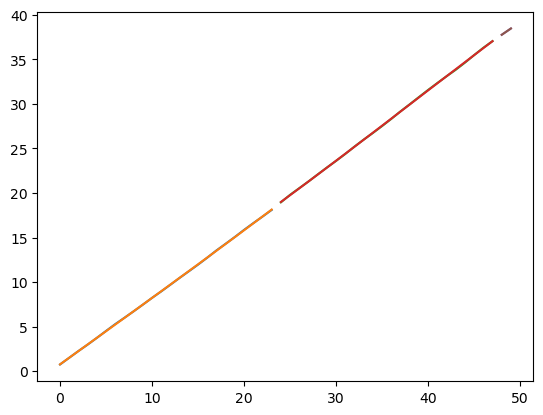

In [61]:
y=B[0:50]
s=12
x = np.arange(len(y))
segment_length = 2*s
# numero di segmenti su cui fare sliding

for k in range(0, len(y), segment_length):
    # prendo un segmento e faccio fit
    x_slice = x[k:k+segment_length]
    y_slice = y[k:k+segment_length]
    y_fitted = poly_fit(x_slice, y_slice, order=3)
    plt.plot(x_slice, y_slice)
    plt.plot(x_slice, y_fitted)
    dev = y_slice-y_fitted